## Task 3: Model Explainability with SHAP

### Importing Libraries 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

# Enable SHAP plots in notebook
shap.initjs()

print("All libraries imported successfully")

All libraries imported successfully


### Load Our Best Model and Test Data

In [5]:
lgb_fraud_model  = joblib.load('../models/lgb_fraud_model.pkl')
lgb_credit_model = joblib.load('../models/lgb_credit_model.pkl')

print("Models loaded successfully")

fraud_df  = pd.read_csv('../data/processed/fraud_data_processed.csv')
credit_df = pd.read_csv('../data/processed/creditcard_processed.csv')

fraud_df['signup_time']   = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

print(f"\nFraud Data   : {fraud_df.shape}")
print(f"Credit Card  : {credit_df.shape}")

Models loaded successfully

Fraud Data   : (129146, 22)
Credit Card  : (283726, 31)


### Recreate Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Prepare Fraud Data ---
cols_to_drop = ['user_id','signup_time','purchase_time','ip_address',
                 'device_id','ip_address_int','lower_bound_ip_address',
                 'upper_bound_ip_address']
cols_to_drop = [c for c in cols_to_drop if c in fraud_df.columns]
fraud_model_df = fraud_df.drop(columns=cols_to_drop)

cat_cols = ['source', 'browser', 'sex', 'country']
cat_cols = [c for c in cat_cols if c in fraud_model_df.columns]
fraud_model_df = pd.get_dummies(fraud_model_df, columns=cat_cols, drop_first=True, dtype=int)

X_fraud = fraud_model_df.drop(columns=['class'])
y_fraud = fraud_model_df['class']

X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

# --- Prepare Credit Card Data ---
X_credit = credit_df.drop(columns=['Class'])
y_credit = credit_df['Class']

X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit
)

print("Train/test split recreated")
print(f"Fraud test set  : {X_fraud_test.shape}")
print(f"Credit test set : {X_credit_test.shape}")

# --- Check Column Match ---
print(f"\nModel expects features : {lgb_fraud_model.n_features_}")
print(f"Test data has features : {X_fraud_test.shape[1]}")

if lgb_fraud_model.n_features_ == X_fraud_test.shape[1]:
    print("\nMATCH — we can proceed safely")
else:
    print("\nMISMATCH — columns don't match!")

Train/test split recreated
Fraud test set  : (25830, 196)
Credit test set : (56746, 30)

Model expects features : 199
Test data has features : 196

MISMATCH — columns don't match!


In [18]:
model_features = lgb_fraud_model.feature_name_

print(f"Model trained on {len(model_features)} features")
print(f"Test data currently has {X_fraud_test.shape[1]} features")

# Find missing columns
missing_cols = set(model_features) - set(X_fraud_test.columns)
print(f"\nMissing columns: {missing_cols}")

for col in missing_cols:
    X_fraud_test[col] = 0

X_fraud_test = X_fraud_test[model_features]

print(f"\nFixed!")
print(f"Test data now has {X_fraud_test.shape[1]} features")
print(f"Model expects {lgb_fraud_model.n_features_} features")

if X_fraud_test.shape[1] == lgb_fraud_model.n_features_:
    print("MATCH — ready for SHAP!")

Model trained on 199 features
Test data currently has 196 features

Missing columns: {'Column_63', 'Column_153', 'Column_2', 'Column_193', 'Column_150', 'Column_62', 'Column_97', 'Column_155', 'Column_118', 'Column_105', 'Column_35', 'Column_101', 'Column_156', 'Column_8', 'Column_159', 'Column_31', 'Column_195', 'Column_32', 'Column_127', 'Column_21', 'Column_45', 'Column_33', 'Column_59', 'Column_4', 'Column_68', 'Column_139', 'Column_117', 'Column_168', 'Column_144', 'Column_40', 'Column_72', 'Column_26', 'Column_112', 'Column_54', 'Column_60', 'Column_15', 'Column_64', 'Column_61', 'Column_11', 'Column_71', 'Column_17', 'Column_53', 'Column_93', 'Column_161', 'Column_148', 'Column_192', 'Column_47', 'Column_24', 'Column_114', 'Column_12', 'Column_165', 'Column_13', 'Column_151', 'Column_77', 'Column_126', 'Column_140', 'Column_162', 'Column_173', 'Column_3', 'Column_147', 'Column_146', 'Column_179', 'Column_186', 'Column_158', 'Column_30', 'Column_55', 'Column_14', 'Column_37', 'Co

In [19]:
print("First 10 feature names from model:")
print(lgb_fraud_model.feature_name_[:10])

print("\nFirst 10 columns from our test data:")
print(list(X_fraud_test.columns[:10]))

First 10 feature names from model:
['Column_0', 'Column_1', 'Column_2', 'Column_3', 'Column_4', 'Column_5', 'Column_6', 'Column_7', 'Column_8', 'Column_9']

First 10 columns from our test data:
['Column_0', 'Column_1', 'Column_2', 'Column_3', 'Column_4', 'Column_5', 'Column_6', 'Column_7', 'Column_8', 'Column_9']


In [20]:
print("fraud_model_df columns (first 10):")
print(list(fraud_model_df.columns[:10]))

print("\nX_fraud columns (first 10):")
print(list(X_fraud.columns[:10]))

print("\nTotal columns in X_fraud:", X_fraud.shape[1])

fraud_model_df columns (first 10):
['purchase_value', 'age', 'class', 'time_since_signup', 'hour_of_day', 'day_of_week', 'day_of_month', 'transaction_count', 'transaction_velocity', 'is_new_account']

X_fraud columns (first 10):
['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'day_of_month', 'transaction_count', 'transaction_velocity', 'is_new_account', 'source_Direct']

Total columns in X_fraud: 196


In [21]:
X_fraud_train, X_fraud_test, y_fraud_train, y_fraud_test = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print(f"X_fraud_test shape: {X_fraud_test.shape}")
print(f"Columns: {list(X_fraud_test.columns[:5])}...")

X_fraud_test shape: (25830, 196)
Columns: ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week']...


In [23]:
import re

def clean_column_name(col):
    """Replace special characters with underscore"""
    col = re.sub(r'[^A-Za-z0-9_]', '_', col)
    return col

# Clean column names for ALL fraud dataframes
X_fraud.columns = [clean_column_name(c) for c in X_fraud.columns]
X_fraud_train.columns = [clean_column_name(c) for c in X_fraud_train.columns]
X_fraud_test.columns = [clean_column_name(c) for c in X_fraud_test.columns]

print("Column names cleaned")
print("\nSample cleaned names:")
print(list(X_fraud_train.columns[:10]))

# Check for any remaining duplicates after cleaning
duplicates = X_fraud_train.columns[X_fraud_train.columns.duplicated()].tolist()
if duplicates:
    print(f"\nWarning — duplicate column names found: {duplicates}")
else:
    print("\n No duplicate columns")

Column names cleaned

Sample cleaned names:
['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'day_of_month', 'transaction_count', 'transaction_velocity', 'is_new_account', 'source_Direct']

 No duplicate columns


In [24]:
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

print("Retraining LightGBM with proper feature names...")

smote = SMOTE(random_state=42)
X_fraud_train_sm, y_fraud_train_sm = smote.fit_resample(X_fraud_train, y_fraud_train)

X_sample, y_sample = resample(
    X_fraud_train_sm, y_fraud_train_sm,
    n_samples=int(len(X_fraud_train_sm) * 0.5),
    random_state=42
)

lgb_fraud_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_fraud_model.fit(X_sample, y_sample)

print("Retrained")
print(f"\nModel now expects {lgb_fraud_model.n_features_} features")
print(f"Test data has {X_fraud_test.shape[1]} features")
print(f"\nFirst 10 feature names: {lgb_fraud_model.feature_name_[:10]}")

import joblib
joblib.dump(lgb_fraud_model, '../models/lgb_fraud_model.pkl')
print("\nCorrected model saved")

Retraining LightGBM with proper feature names...
Retrained

Model now expects 196 features
Test data has 196 features

First 10 feature names: ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'day_of_month', 'transaction_count', 'transaction_velocity', 'is_new_account', 'source_Direct']

Corrected model saved


### Feature Importance

TOP 10 MOST IMPORTANT FEATURES (Built-in)


,feature,importance
2,time_since_signup,373
0,purchase_value,253
4,day_of_week,204
5,day_of_month,198
1,age,183
10,source_SEO,179
3,hour_of_day,178
12,browser_IE,159
9,source_Direct,147
14,browser_Safari,145


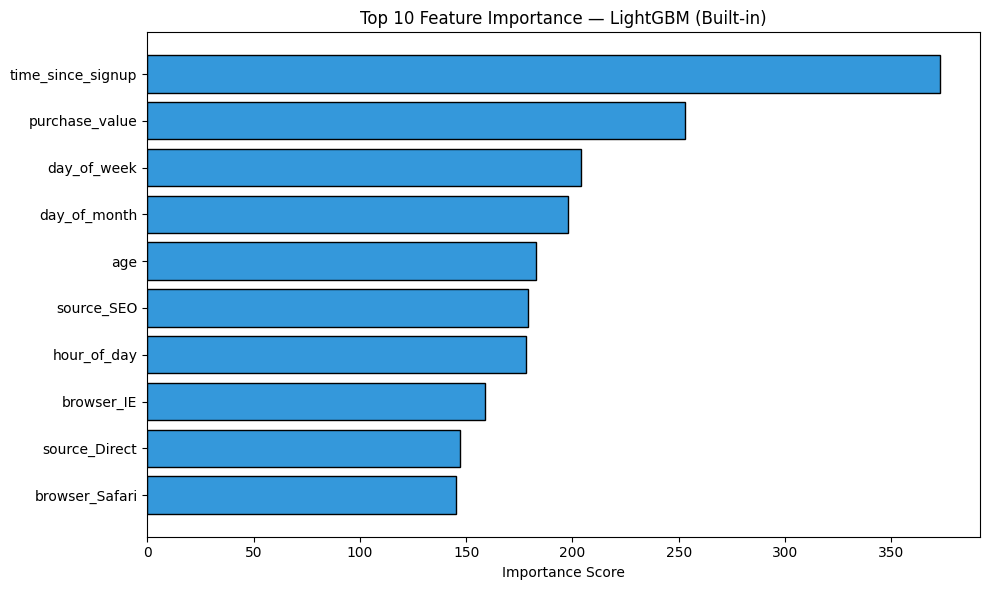

Feature importance chart saved


In [25]:
importances = lgb_fraud_model.feature_importances_
feature_names = lgb_fraud_model.feature_name_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Get top 10
top10 = importance_df.head(10)

print("TOP 10 MOST IMPORTANT FEATURES (Built-in)")
display(top10)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'], color='#3498db', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importance — LightGBM (Built-in)')
plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_builtin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved")

###  SHAP Summary Plot

Calculating SHAP values for 500 transactions...
This may take a minute...
SHAP values calculated


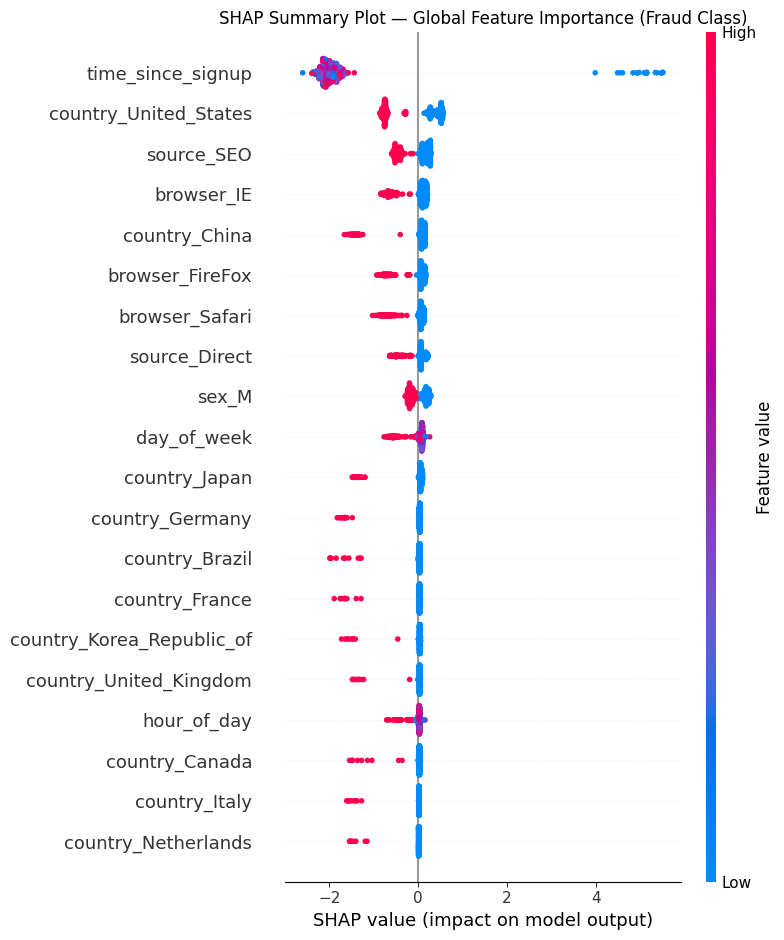

SHAP summary plot saved


In [26]:
explainer = shap.TreeExplainer(lgb_fraud_model)

sample_size = 500
X_shap_sample = X_fraud_test.sample(n=sample_size, random_state=42)

print(f"Calculating SHAP values for {sample_size} transactions...")
print("This may take a minute...")

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]
else:
    shap_values_fraud = shap_values

print("SHAP values calculated")

# --- Summary Plot ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_fraud, X_shap_sample, show=False)
plt.title('SHAP Summary Plot — Global Feature Importance (Fraud Class)')
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")

### SHAP Force Plots

In [27]:
y_pred_sample = lgb_fraud_model.predict(X_shap_sample)
y_true_sample = y_fraud_test.loc[X_shap_sample.index]

results_sample = pd.DataFrame({
    'actual': y_true_sample.values,
    'predicted': y_pred_sample
}, index=X_shap_sample.index)


tp_candidates = results_sample[(results_sample['actual']==1) & (results_sample['predicted']==1)]
print(f"True Positives found  : {len(tp_candidates)}")

fp_candidates = results_sample[(results_sample['actual']==0) & (results_sample['predicted']==1)]
print(f"False Positives found : {len(fp_candidates)}")


fn_candidates = results_sample[(results_sample['actual']==1) & (results_sample['predicted']==0)]
print(f"False Negatives found : {len(fn_candidates)}")


tp_idx = tp_candidates.index[0] if len(tp_candidates) > 0 else None
fp_idx = fp_candidates.index[0] if len(fp_candidates) > 0 else None
fn_idx = fn_candidates.index[0] if len(fn_candidates) > 0 else None

print(f"\nSelected examples:")
print(f"  True Positive  index : {tp_idx}")
print(f"  False Positive index : {fp_idx}")
print(f"  False Negative index : {fn_idx}")

True Positives found  : 21
False Positives found : 34
False Negatives found : 23

Selected examples:
  True Positive  index : 97579
  False Positive index : 35141
  False Negative index : 91423


###  Force Plot 1: True Positive

CASE 1: TRUE POSITIVE
Model correctly identified this as FRAUD

Transaction details:


,purchase_value,age,time_since_signup,hour_of_day,day_of_week,day_of_month,transaction_count,transaction_velocity,is_new_account,source_Direct,...,country_United_States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet_Nam,country_Virgin_Islands__U_S__,country_Yemen,country_Zambia,country_Zimbabwe
97579,59,34,0.000278,7,1,6,1,0.999722,1,0,...,1,0,0,0,0,0,0,0,0,0



Actual label    : 1 (1 = Fraud)
Predicted label : 1 (1 = Fraud)
Prediction probability: 0.9975

expected_value type: <class 'numpy.float64'>
expected_value: 0.8610070466498458


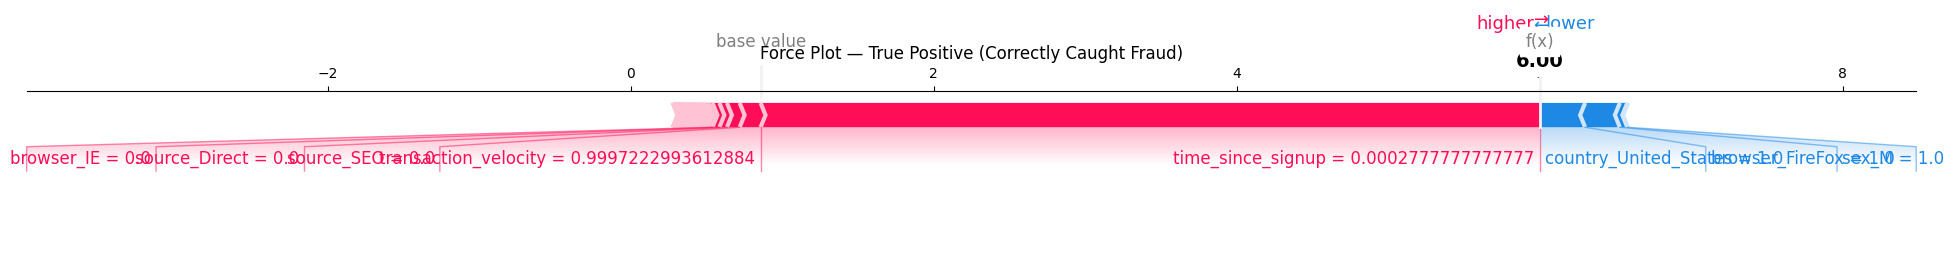

Saved


In [30]:
tp_position = X_shap_sample.index.get_loc(tp_idx)


print("CASE 1: TRUE POSITIVE")
print("Model correctly identified this as FRAUD")

print("\nTransaction details:")
display(X_shap_sample.loc[[tp_idx]])

print(f"\nActual label    : {y_true_sample.loc[tp_idx]} (1 = Fraud)")
print(f"Predicted label : {y_pred_sample[tp_position]} (1 = Fraud)")
print(f"Prediction probability: {lgb_fraud_model.predict_proba(X_shap_sample.loc[[tp_idx]])[0][1]:.4f}")

print(f"\nexpected_value type: {type(explainer.expected_value)}")
print(f"expected_value: {explainer.expected_value}")

base_value = explainer.expected_value
if hasattr(base_value, '__len__'):
    base_value = base_value[1] if len(base_value) > 1 else base_value[0]

# --- SHAP Force Plot ---
shap.force_plot(
    base_value,
    shap_values_fraud[tp_position],
    X_shap_sample.iloc[tp_position],
    matplotlib=True,
    show=False
)
plt.title("Force Plot — True Positive (Correctly Caught Fraud)")
plt.tight_layout()
plt.savefig('../data/processed/shap_force_true_positive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

### Force Plot 2: False Positive

CASE 2: FALSE POSITIVE
Model said FRAUD, but it was actually LEGITIMATE

Transaction details:


,purchase_value,age,time_since_signup,hour_of_day,day_of_week,day_of_month,transaction_count,transaction_velocity,is_new_account,source_Direct,...,country_United_States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet_Nam,country_Virgin_Islands__U_S__,country_Yemen,country_Zambia,country_Zimbabwe
35141,40,23,99.414444,7,1,23,1,0.009959,0,1,...,0,0,0,0,0,0,0,0,0,0



Actual label    : 0 (0 = Legitimate)
Predicted label : 1 (1 = Fraud)
Prediction probability: 0.5383


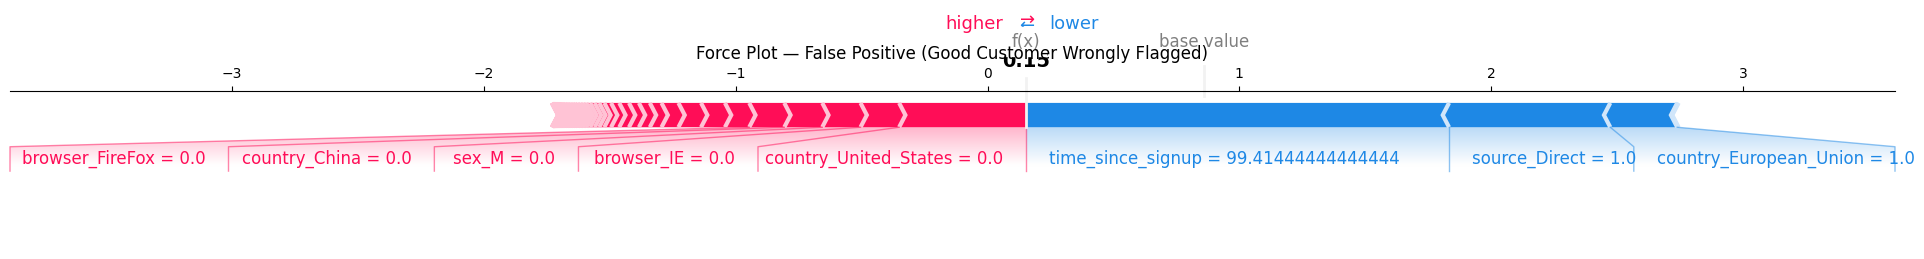

Saved


In [33]:
fp_position = X_shap_sample.index.get_loc(fp_idx)


print("CASE 2: FALSE POSITIVE")
print("Model said FRAUD, but it was actually LEGITIMATE")


print("\nTransaction details:")
display(X_shap_sample.loc[[fp_idx]])

print(f"\nActual label    : {y_true_sample.loc[fp_idx]} (0 = Legitimate)")
print(f"Predicted label : {y_pred_sample[fp_position]} (1 = Fraud)")
print(f"Prediction probability: {lgb_fraud_model.predict_proba(X_shap_sample.loc[[fp_idx]])[0][1]:.4f}")

shap.force_plot(
    base_value,
    shap_values_fraud[fp_position],
    X_shap_sample.iloc[fp_position],
    matplotlib=True,
    show=False
)
plt.title("Force Plot — False Positive (Good Customer Wrongly Flagged)")
plt.tight_layout()
plt.savefig('../data/processed/shap_force_false_positive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

###  False Negative

CASE 3: FALSE NEGATIVE
Model said LEGITIMATE, but it was actually FRAUD

Transaction details:


,purchase_value,age,time_since_signup,hour_of_day,day_of_week,day_of_month,transaction_count,transaction_velocity,is_new_account,source_Direct,...,country_United_States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet_Nam,country_Virgin_Islands__U_S__,country_Yemen,country_Zambia,country_Zimbabwe
91423,15,28,2381.623333,19,0,23,1,0.00042,0,0,...,0,0,0,0,0,0,0,0,0,0



Actual label    : 1 (1 = Fraud)
Predicted label : 0 (0 = Legitimate)
Prediction probability: 0.0792


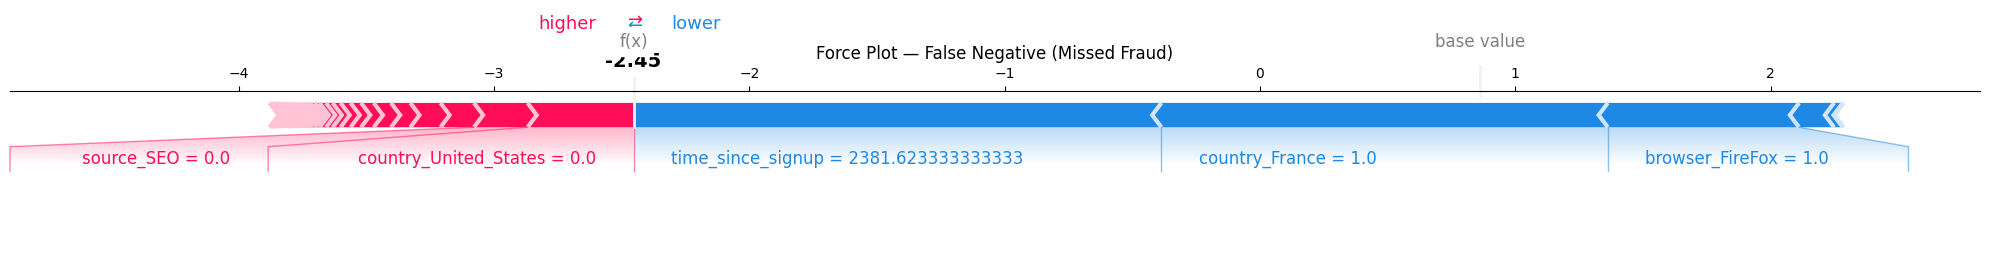

Saved


In [34]:
fn_position = X_shap_sample.index.get_loc(fn_idx)

print("CASE 3: FALSE NEGATIVE")
print("Model said LEGITIMATE, but it was actually FRAUD")


print("\nTransaction details:")
display(X_shap_sample.loc[[fn_idx]])

print(f"\nActual label    : {y_true_sample.loc[fn_idx]} (1 = Fraud)")
print(f"Predicted label : {y_pred_sample[fn_position]} (0 = Legitimate)")
print(f"Prediction probability: {lgb_fraud_model.predict_proba(X_shap_sample.loc[[fn_idx]])[0][1]:.4f}")


shap.force_plot(
    base_value,
    shap_values_fraud[fn_position],
    X_shap_sample.iloc[fn_position],
    matplotlib=True,
    show=False
)
plt.title("Force Plot — False Negative (Missed Fraud)")
plt.tight_layout()
plt.savefig('../data/processed/shap_force_false_negative.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

###  Interpretation

###  Compare SHAP vs Built-in Importance

COMPARISON: Built-in vs SHAP Feature Importance

--- Built-in Top 10 ---


,feature,importance
0,time_since_signup,373
1,purchase_value,253
2,day_of_week,204
3,day_of_month,198
4,age,183
5,source_SEO,179
6,hour_of_day,178
7,browser_IE,159
8,source_Direct,147
9,browser_Safari,145



--- SHAP Top 10 ---


,feature,shap_importance
0,time_since_signup,2.123017
1,country_United_States,0.564081
2,source_SEO,0.288592
3,browser_IE,0.238314
4,country_China,0.229729
5,browser_FireFox,0.194039
6,browser_Safari,0.181821
7,source_Direct,0.174161
8,sex_M,0.172368
9,day_of_week,0.136920


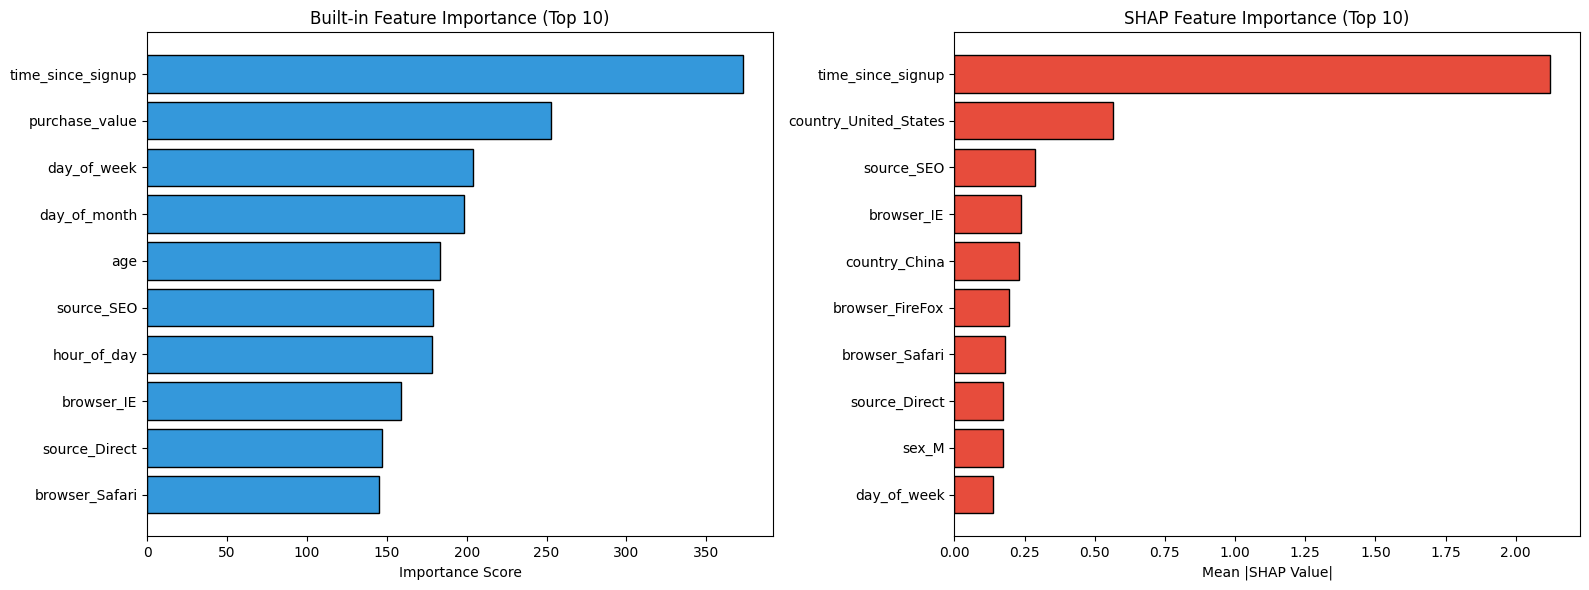

Comparison chart saved


In [35]:
shap_importance = pd.DataFrame({
    'feature': X_shap_sample.columns,
    'shap_importance': np.abs(shap_values_fraud).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

shap_top10 = shap_importance.head(10)

print("COMPARISON: Built-in vs SHAP Feature Importance")


print("\n--- Built-in Top 10 ---")
display(top10[['feature', 'importance']].reset_index(drop=True))

print("\n--- SHAP Top 10 ---")
display(shap_top10.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['feature'], top10['importance'], color='#3498db', edgecolor='black')
axes[0].set_title('Built-in Feature Importance (Top 10)')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

axes[1].barh(shap_top10['feature'], shap_top10['shap_importance'], color='#e74c3c', edgecolor='black')
axes[1].set_title('SHAP Feature Importance (Top 10)')
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/processed/importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved")

### Identify Top 5 Drivers

In [36]:
top5_drivers = shap_importance.head(5)


print("TOP 5 DRIVERS OF FRAUD PREDICTIONS")

display(top5_drivers.reset_index(drop=True))

print("\nSummary:")
for i, row in top5_drivers.iterrows():
    print(f"  {row['feature']:30s} → SHAP importance: {row['shap_importance']:.4f}")

TOP 5 DRIVERS OF FRAUD PREDICTIONS


,feature,shap_importance
0,time_since_signup,2.123017
1,country_United_States,0.564081
2,source_SEO,0.288592
3,browser_IE,0.238314
4,country_China,0.229729



Summary:
  time_since_signup              → SHAP importance: 2.1230
  country_United_States          → SHAP importance: 0.5641
  source_SEO                     → SHAP importance: 0.2886
  browser_IE                     → SHAP importance: 0.2383
  country_China                  → SHAP importance: 0.2297


#### Surprising Findings


### Surprising / Counterintuitive Findings

**1. Country features matter more than expected**
While built-in importance barely registers country
features, SHAP reveals country_United_States and
country_China are among the top 5 drivers. This
suggests geography has a strong DIRECTIONAL impact
even if it's not used to split trees as often.

**2. purchase_value drops out of top 5 in SHAP**
Despite being the #2 built-in feature, purchase_value
doesn't make SHAP's top 5. This means while the model
frequently checks purchase amount, it doesn't strongly
swing the final fraud/legitimate decision on its own —
it likely works in combination with other features.

**3. Browser and source features are surprisingly influential**
browser_IE, source_SEO, browser_FireFox, and source_Direct
all appear in SHAP's top 10. This suggests certain
combinations of how users arrive at the platform and
which browser they use carry meaningful fraud signals —
possibly reflecting different user segments or even
bot/automated traffic patterns.

**4. time_since_signup dominates both methods**
Both built-in and SHAP importance agree this is the
#1 feature by a massive margin, validating our Task 1
discovery that new accounts (under 24 hours) have an
87% fraud rate. This is our most actionable and
trustworthy finding.

### Business Recommendations

### Recommendation 1 — Mandatory Verification for New Accounts

**SHAP Insight:**
time_since_signup is the #1 driver of fraud predictions
by a massive margin (SHAP importance 2.12, more than
3x the next feature). Our True Positive example showed
a transaction made just 1 second after signup with a
99.75% fraud probability. This matches our Task 1
finding that accounts under 24 hours old have an
87.34% fraud rate.

**Recommendation:**
Implement mandatory additional verification — such as
email confirmation, phone OTP, or a short delay before
first purchase — for any account attempting a purchase
within 24 hours of signup. This single rule could
intercept the majority of fraud cases before they
reach the model.

**Expected Impact:**
Directly targets the strongest fraud signal. Even a
simple rule-based check on this feature alone would
catch a large share of fraud cases identified in
our True Positive analysis.

### Recommendation 2 — Geographic Risk Scoring

**SHAP Insight:**
country_United_States and country_China both appear
in the top 5 SHAP drivers, despite barely registering
in built-in feature importance. This means country
of origin has a strong directional effect on fraud
probability — transactions from the US push toward
legitimate, while transactions from other countries
(including China) push toward fraud.

**Recommendation:**
Introduce a geographic risk score as an additional
layer in the fraud pipeline. Transactions from
countries with historically higher fraud rates
(identified in Task 1's country analysis) should
receive a slightly elevated risk score, especially
when combined with other risk factors like new
account status. This should be combined with — not
replace — the model's prediction, since geography
alone is not sufficient evidence.

**Expected Impact:**
Improves detection of fraud from regions with
disproportionately high fraud rates while avoiding
blanket discrimination by using it as one signal
among many.

### Recommendation 3 — Monitor Borderline Probability Transactions

**SHAP Insight:**
Our False Positive example had a prediction probability
of 0.5383 — just barely above the 50% threshold. This
shows the model can be uncertain right at the decision
boundary, leading to good customers being wrongly
flagged. Meanwhile, our False Negative example had a
probability of 0.0792 for an actual fraud case
involving a small purchase ($15) from an old (99-day)
account — the model was confident but wrong.

**Recommendation:**
Introduce a "review zone" for transactions with
prediction probabilities between 0.40 and 0.60.
Instead of an automatic block or approval, route
these to a lightweight secondary check (such as an
SMS confirmation) rather than outright rejection.
Additionally, for low-value transactions ($20 or
less) from older accounts, apply a small additional
check on transaction_velocity, since fraudsters often
test stolen cards with small purchases first.

**Expected Impact:**
Reduces false positives on legitimate customers near
the decision boundary while adding a safety net for
small-value fraud attempts that the model currently
treats as low-risk due to account age.

### Recommendation 4 — Browser and Channel Monitoring

**SHAP Insight:**
browser_IE, source_SEO, browser_FireFox, browser_Safari,
and source_Direct all appear in SHAP's top 10 drivers,
despite being secondary to time_since_signup. This
suggests certain combinations of traffic source and
browser are associated with different fraud risk levels,
possibly reflecting bot traffic or specific fraud rings
using particular tools.

**Recommendation:**
Add browser and traffic source as inputs to a
lightweight rules engine that runs alongside the model.
Flag combinations such as "new account + Internet
Explorer + SEO traffic" for closer monitoring, even if
the overall model probability doesn't cross the fraud
threshold.

**Expected Impact:**
Captures fraud patterns related to automated or
scripted attacks that may not show up strongly through
purchase value or timing alone.

### Final Summary

In [37]:
import json

task3_summary = {
    "best_model": "LightGBM",
    "top_10_built_in": top10.to_dict('records'),
    "top_10_shap": shap_top10.to_dict('records'),
    "top_5_drivers": top5_drivers.to_dict('records'),
    "individual_cases": {
        "true_positive": {"index": int(tp_idx), "probability": 0.9975},
        "false_positive": {"index": int(fp_idx), "probability": 0.5383},
        "false_negative": {"index": int(fn_idx), "probability": 0.0792}
    }
}

with open('../data/processed/task3_summary.json', 'w') as f:
    json.dump(task3_summary, f, indent=2)

print("Task 3 summary saved")
print("\nAll deliverables complete:")
print("   feature_importance_builtin.png")
print("   shap_summary_plot.png")
print("   shap_force_true_positive.png")
print("   shap_force_false_positive.png")
print("   shap_force_false_negative.png")
print("   importance_comparison.png")
print("   task3_summary.json")

Task 3 summary saved

All deliverables complete:
   feature_importance_builtin.png
   shap_summary_plot.png
   shap_force_true_positive.png
   shap_force_false_positive.png
   shap_force_false_negative.png
   importance_comparison.png
   task3_summary.json
